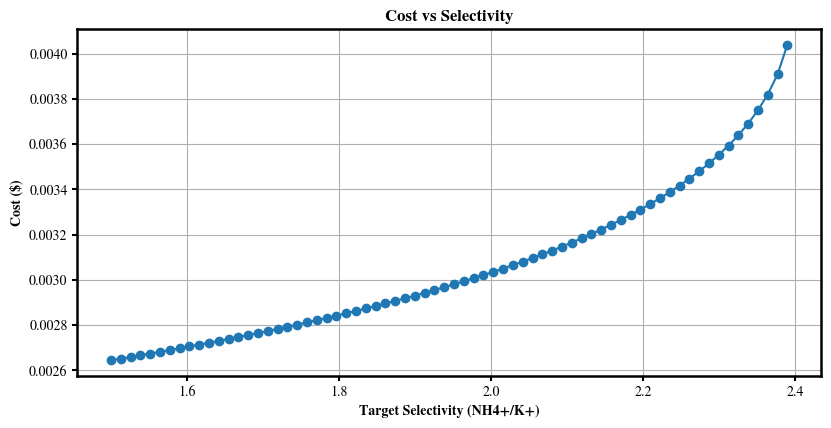

In [2]:
# Import library functions
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt


# Parameters
cost_per_area = 20.0
selectivity_range = np.linspace(1.50, 2.39, 70)
beta_pressure = 0.0

# Permeance correlation from experimental data
def NH4_permeance(GA_concentration):
    # (a * x + b) / (x + c)
    a = 50.89880557586272
    b = 59.22236814216997
    c = 0.3904348394108801
    x = GA_concentration
    return (a * x + b) / (x + c)

def K_permeance(GA_concentration):
    # (a * x + b) / (x + c)
    a = 26.737552013096316
    b = 10.571037538897821
    c = 0.10363218641001229
    x = GA_concentration
    return (a * x + b) / (x + c)

def selectivity_ratio(GA_concentration):
    return NH4_permeance(GA_concentration) / K_permeance(GA_concentration)


# Mass balances
def driving_force(permeance, P_diff):
    return permeance * P_diff

def permeation_rate(driving_force_value, A):
    return driving_force_value * A  # mol/h

def NH4_flow_rate_constraint(params):
    GA_conc, P_diff, A = params
    NH4_perm = NH4_permeance(GA_conc)
    flow_rate_NH4 = permeation_rate(driving_force(NH4_perm, P_diff), A)
    return flow_rate_NH4 - 0.4  # Flow rate should be >= 0.4 mol/h

def selectivity_eq_constraint_factory(target_selectivity):
    def _eq(params):
        GA_conc = params[0]
        return selectivity_ratio(GA_conc) - target_selectivity
    return _eq

def objective_area_plus_pressure(params):
    _, P_diff, A = params
    return A + beta_pressure * (P_diff / 20.0)

def compute_cost(area):
    return cost_per_area * area

# Bounds & initial guess
# GA in [0, 2.5], P_diff in [0.1, 20], A in [1e-4, 1]
bounds = [(0.0, 2.5), (0.1, 20.0), (1e-4, 1.0)]
initial_guess = np.array([0.3, 6.9, 14.6e-4], dtype=float)

# Solve across selectivity sweep
costs = []
areas = []
ga_concentrations = []
pressures = []
success_flags = []

x0 = initial_guess.copy()

for target_sel in selectivity_range:
    constraints = [
        {'type': 'ineq', 'fun': NH4_flow_rate_constraint},
        {'type': 'eq',   'fun': selectivity_eq_constraint_factory(target_sel)}
    ]

    result = minimize(
        objective_area_plus_pressure,
        x0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 1000}
    )

    if not result.success:
        x0_fallback = np.array([min(max(x0[0], bounds[0][0]), bounds[0][1]),
                                19.9,     # near the upper pressure bound
                                max(1.0e-4, x0[2])], dtype=float)
        result = minimize(
            objective_area_plus_pressure,
            x0_fallback,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'ftol': 1e-12, 'maxiter': 1000}
        )

    success = bool(result.success)
    success_flags.append(success)

    if success:
        GA_opt, P_opt, A_opt = result.x
        areas.append(A_opt)
        costs.append(compute_cost(A_opt))
        ga_concentrations.append(GA_opt)
        pressures.append(P_opt)
        x0 = result.x
    else:
        areas.append(np.nan)
        costs.append(np.nan)
        ga_concentrations.append(np.nan)
        pressures.append(np.nan)

costs = np.array(costs)
areas = np.array(areas)
ga_concentrations = np.array(ga_concentrations)
pressures = np.array(pressures)
success_flags = np.array(success_flags)

# Basic sanity checks
n_fail = np.sum(~success_flags)
if n_fail > 0:
    print(f"Warning: {n_fail} optimization(s) did not report success. Points are NaN in plots.")

# Plotting
plt.figure(figsize=(16, 8))

ax1 = plt.subplot(2, 2, 1)
ax1.plot(selectivity_range, costs, marker='o')
ax1.set_xlabel('Target Selectivity (NH4+/K+)')
ax1.set_ylabel('Cost ($)')
ax1.set_title(f'Cost vs Selectivity')
ax1.grid(True)

plt.tight_layout()
plt.show()

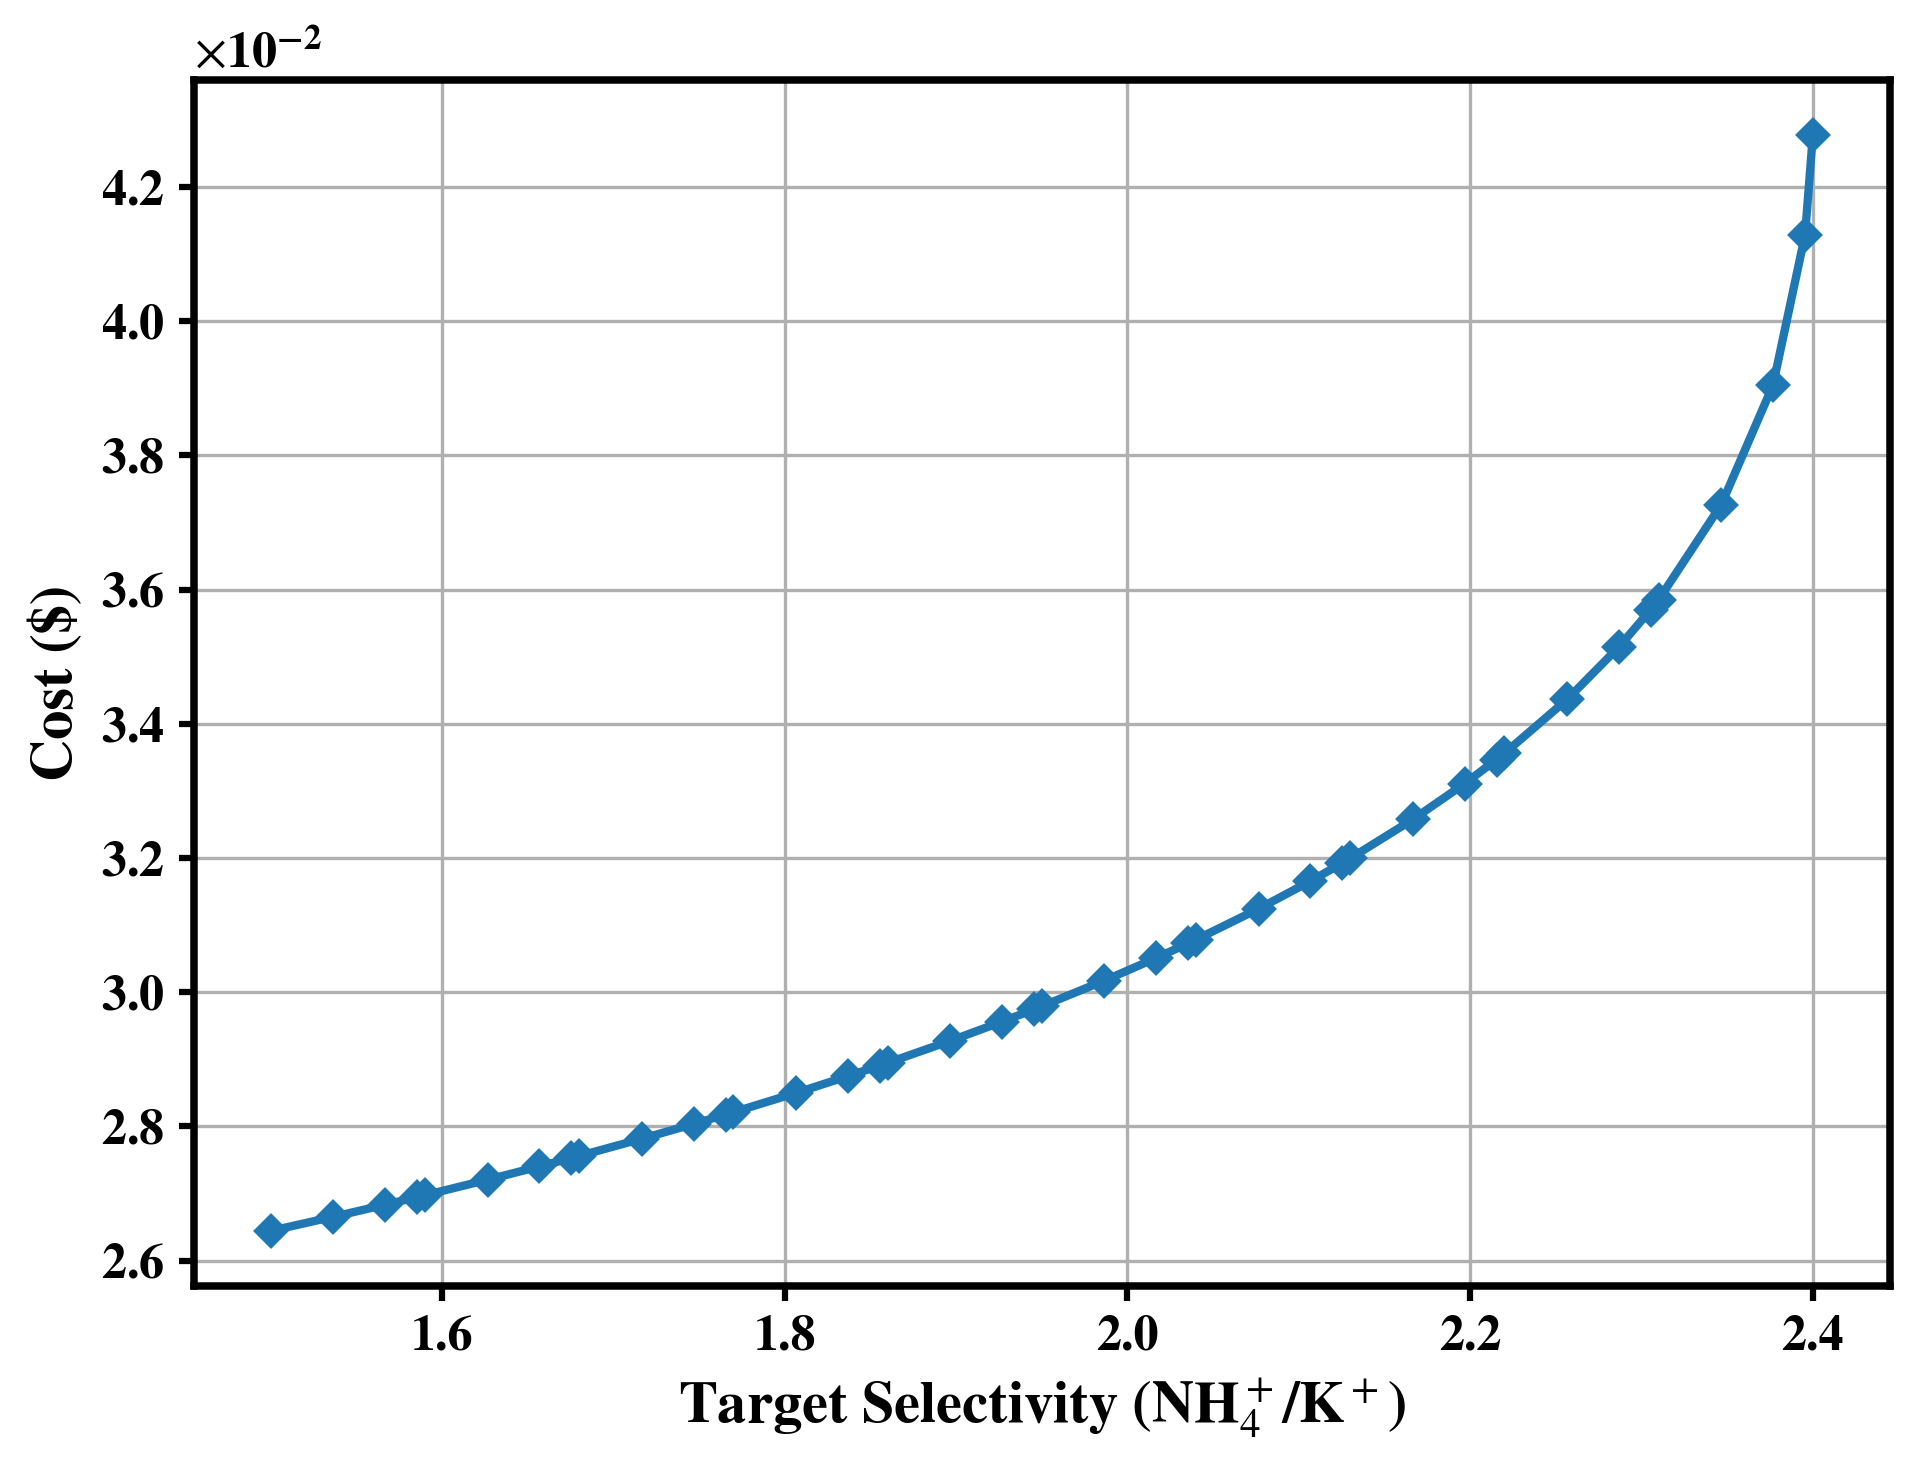

In [4]:
### OCFE Model Embedded into the Optimization
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Problem definitions
cost_per_area = 200.0
beta_pressure = 0.0

sel_min, sel_max = 1.50, 2.40
selectivity_range = np.linspace(sel_min, sel_max, 70)

def NH4_permeance(x):
    a = 50.89880557586272
    b = 59.22236814216997
    c = 0.3904348394108801
    return (a * x + b) / (x + c)

def K_permeance(x):
    a = 26.737552013096316
    b = 10.571037538897821
    c = 0.10363218641001229
    return (a * x + b) / (x + c)

def selectivity_ratio(x):
    return NH4_permeance(x) / K_permeance(x)

def compute_cost(area):
    return cost_per_area * area

# 5-point roots
s_rel = np.array([0.0, 0.40585, 0.74153, 0.94911, 1.0], dtype=float)

# Bounds: GA in [0, 2.5], P_diff in [0.1, 20], A in [1e-4, 1]
lb = np.array([0.0, 0.1, 1e-4])
ub = np.array([2.5, 20.0, 1.0])

# Baseline (pointwise) sweep for a good initial guess curve
def pointwise_solve_for_target_sel(target_sel, x0):
    def nh4_flow_ineq(x):
        GA, P, A = x
        return NH4_permeance(GA) * P * A - 0.4  # >= 0

    def sel_eq(x):
        return selectivity_ratio(x[0]) - target_sel

    def obj(x):
        _, P, A = x
        return A + beta_pressure * (P / 20.0)

    cons = [
        {"type": "ineq", "fun": nh4_flow_ineq},
        {"type": "eq", "fun": sel_eq},
    ]

    res = minimize(
        obj, x0, method="SLSQP", bounds=list(zip(lb, ub)),
        constraints=cons, options={"ftol": 1e-12, "maxiter": 1000}
    )
    if not res.success:
        x0_fb = np.array([np.clip(x0[0], lb[0], ub[0]), 19.9, max(lb[2], x0[2])], dtype=float)
        res = minimize(
            obj, x0_fb, method="SLSQP", bounds=list(zip(lb, ub)),
            constraints=cons, options={"ftol": 1e-12, "maxiter": 1500}
        )
    return res

x0 = np.array([0.3, 6.9, 14.6e-4], dtype=float)

GA_pw, P_pw, A_pw = [], [], []
ok_pw = []
for ts in selectivity_range:
    res = pointwise_solve_for_target_sel(ts, x0)
    ok_pw.append(bool(res.success))
    if res.success:
        x0 = res.x
        GA_pw.append(res.x[0]); P_pw.append(res.x[1]); A_pw.append(res.x[2])
    else:
        GA_pw.append(np.nan); P_pw.append(np.nan); A_pw.append(np.nan)

GA_pw = np.array(GA_pw); P_pw = np.array(P_pw); A_pw = np.array(A_pw)
ok_pw = np.array(ok_pw)

# Fill NaNs (if any) to build a stable OCFE initial guess
def fill_nans_nearest(y):
    y = y.copy()
    mask = np.isfinite(y)
    if not mask.any():
        return np.full_like(y, 0.3)
    idx = np.where(mask)[0]
    for i in range(len(y)):
        if not np.isfinite(y[i]):
            j = idx[np.argmin(np.abs(idx - i))]
            y[i] = y[j]
    return y

GA_pw_f = fill_nans_nearest(GA_pw)
P_pw_f  = fill_nans_nearest(P_pw)
A_pw_f  = fill_nans_nearest(A_pw)

# OCFE parameterization across selectivity domain
nfe = 10
h = (sel_max - sel_min) / nfe

# element k covers [sel_min + k*h, sel_min + (k+1)*h]
sel_points = np.zeros((nfe, len(s_rel)))
for k in range(nfe):
    sel_points[k, :] = sel_min + k*h + s_rel*h

# Flatten decision variables: [GA[k,j], P[k,j], A[k,j]] for all k,j
def pack(GA, P, A):
    return np.concatenate([GA.ravel(), P.ravel(), A.ravel()])

def unpack(x):
    n = nfe * 5
    GA = x[0:n].reshape((nfe, 5))
    P  = x[n:2*n].reshape((nfe, 5))
    A  = x[2*n:3*n].reshape((nfe, 5))
    return GA, P, A

# Initial guess from pointwise curve by interpolation
GA0 = np.zeros((nfe, 5))
P0  = np.zeros((nfe, 5))
A0  = np.zeros((nfe, 5))
for k in range(nfe):
    for j in range(5):
        s = sel_points[k, j]
        GA0[k, j] = np.interp(s, selectivity_range, GA_pw_f)
        P0[k, j]  = np.interp(s, selectivity_range, P_pw_f)
        A0[k, j]  = np.interp(s, selectivity_range, A_pw_f)

x_init = pack(GA0, P0, A0)

# Bounds for all variables
bounds = []
for _ in range(nfe * 5):  # GA
    bounds.append((lb[0], ub[0]))
for _ in range(nfe * 5):  # P
    bounds.append((lb[1], ub[1]))
for _ in range(nfe * 5):  # A
    bounds.append((lb[2], ub[2]))

# Objective
# (simple mean over collocation points j=1..4 in each element)
def ocfe_objective(x):
    GA, P, A = unpack(x)
    eps = 1e-4  # tiny penalty to help keep the stitched curve smooth
    smooth = 0.0
    for k in range(nfe-1):
        smooth += (GA[k,4]-GA[k+1,0])**2 + (P[k,4]-P[k+1,0])**2 + (A[k,4]-A[k+1,0])**2

    base = 0.0
    for k in range(nfe):
        base += np.mean(A[k, 1:]) + beta_pressure * np.mean(P[k, 1:] / 20.0)

    return h * base + eps * smooth

# Constraints:
# 1) selectivity_ratio(GA[k,j]) == sel_points[k,j] for j=1..4
# 2) NH4_permeance(GA[k,j]) * P[k,j] * A[k,j] >= 0.4 for j=1..4
# 3) continuity between elements: (k,4) == (k+1,0) for GA,P,A
def make_constraints():
    cons = []

    def sel_eq_factory(k, j):
        target = sel_points[k, j]
        def _fun(x):
            GA, P, A = unpack(x)
            return selectivity_ratio(GA[k, j]) - target
        return _fun

    def flow_ineq_factory(k, j):
        def _fun(x):
            GA, P, A = unpack(x)
            return NH4_permeance(GA[k, j]) * P[k, j] * A[k, j] - 0.4
        return _fun

    def cont_eq_factory(k, which):
        def _fun(x):
            GA, P, A = unpack(x)
            if which == 0:  return GA[k,4] - GA[k+1,0]
            if which == 1:  return P[k,4]  - P[k+1,0]
            return A[k,4]   - A[k+1,0]
        return _fun

    for k in range(nfe):
        for j in range(1, 5):
            cons.append({"type": "eq",   "fun": sel_eq_factory(k, j)})
            cons.append({"type": "ineq", "fun": flow_ineq_factory(k, j)})

    for k in range(nfe-1):
        for which in (0, 1, 2):
            cons.append({"type": "eq", "fun": cont_eq_factory(k, which)})

    return cons

constraints = make_constraints()

res_ocfe = minimize(
    ocfe_objective,
    x_init,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"ftol": 1e-10, "maxiter": 4000}
)

GA_sol, P_sol, A_sol = unpack(res_ocfe.x)

# Build stitched curve (avoid duplicate boundary points)
sel_curve = []
GA_curve, P_curve, A_curve = [], [], []
for k in range(nfe):
    for j in range(5):
        if k > 0 and j == 0:
            continue
        sel_curve.append(sel_points[k, j])
        GA_curve.append(GA_sol[k, j])
        P_curve.append(P_sol[k, j])
        A_curve.append(A_sol[k, j])

sel_curve = np.array(sel_curve)
GA_curve = np.array(GA_curve)
P_curve  = np.array(P_curve)
A_curve  = np.array(A_curve)

cost_pw = compute_cost(A_pw)
cost_curve = compute_cost(A_curve)

# Plot
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "axes.linewidth": 1.8,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# Create figure
fig, ax = plt.subplots(figsize=(6.5, 5.0), dpi=300)

# Marker + solid line
ax.plot(sel_curve, cost_curve,
        marker='D',
        markersize=5,
        linewidth=2)

# Labels and title
ax.set_xlabel(r"Target Selectivity (NH$_4^+$/K$^+$)", fontsize=14, fontweight='bold')
ax.set_ylabel("Cost ($)", fontsize=14, fontweight='bold')
#ax.set_title("Cost vs Selectivity", fontsize=16, fontweight='bold')

# Scientific multiplier
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))  # use scientific notation
ax.yaxis.set_major_formatter(formatter)

# Make tick labels bold
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(12)

for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(12)

# Make scientific multiplier text bold
ax.yaxis.get_offset_text().set_fontsize(12)
ax.yaxis.get_offset_text().set_fontweight('bold')

# Grid
ax.grid(True)

# Thicker spines
for spine in ax.spines.values():
    spine.set_linewidth(1.8)

fig.tight_layout()
plt.show()